In [8]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from pathlib import Path

In [9]:
RESULTS_DIR = Path("/home/vivekbisht/Desktop/faers-signal-detection/results_private")
FIG_DIR = RESULTS_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

In [10]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14,8)


In [11]:
validation_res= pd.read_csv("/home/vivekbisht/Desktop/faers-signal-detection/results_private/semantic_enhanced_validation.csv")

In [15]:

validation_res['delta_prr'] = (
    validation_res['prr'] - validation_res['baseline_prr']
)

In [ ]:
print(validation_res.columns)

Index(['drug', 'event', 'pooled_cases', 'prr', 'chi2', 'p_value',
       'neighbors_used', 'neighbors', 'is_signal', 'baseline_prr',
       'baseline_n_cases', 'expected_prr', 'description', 'delta_prr'],
      dtype='str')


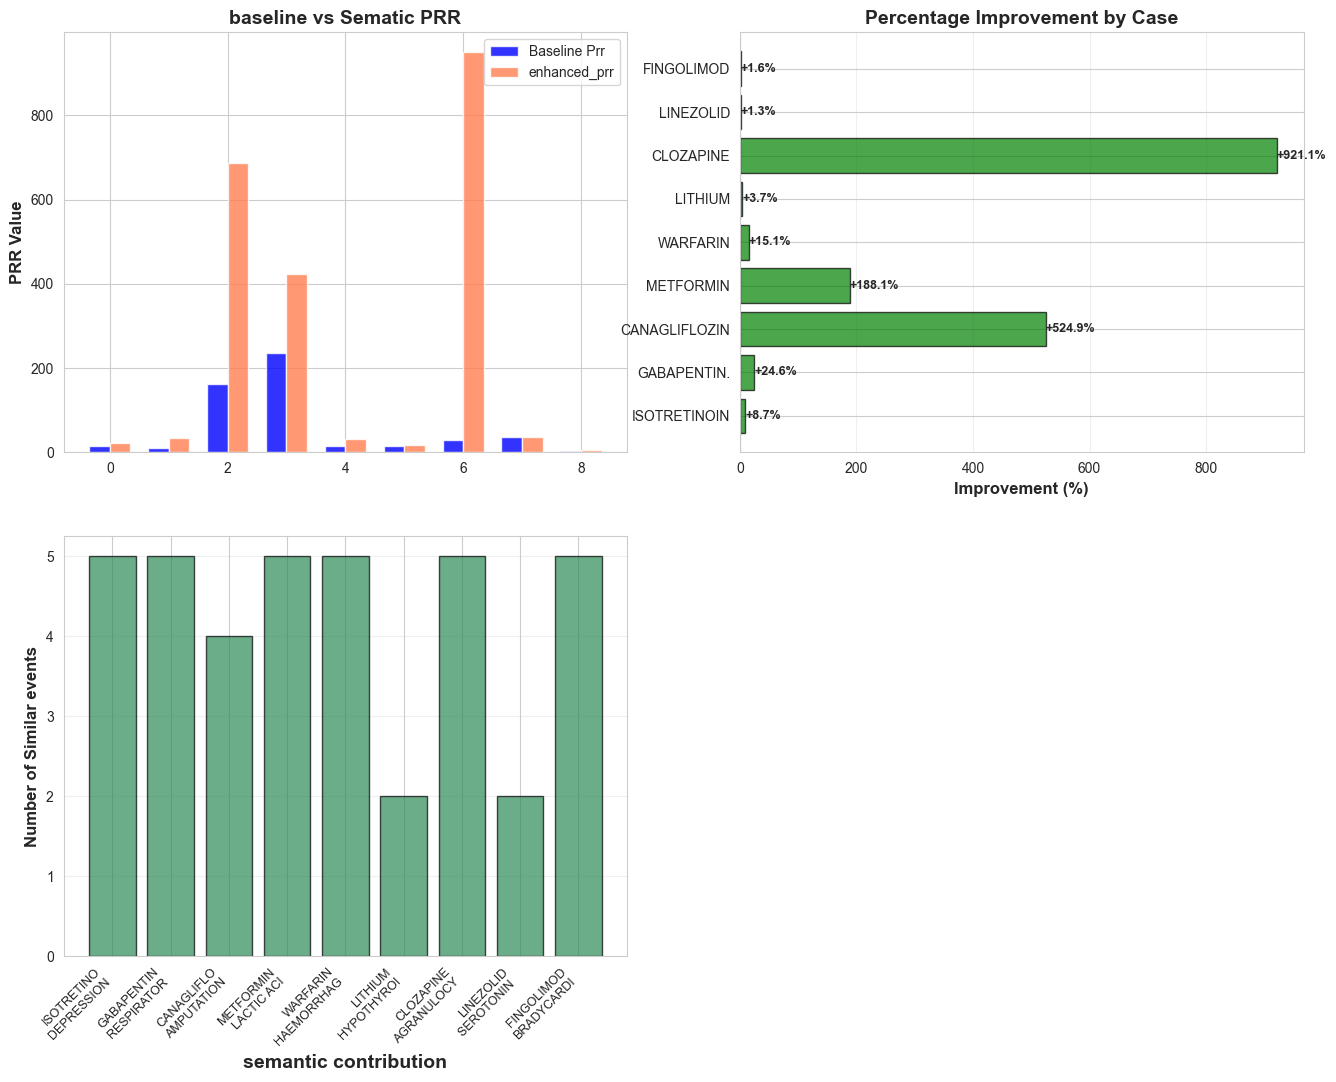

In [24]:
fig,axes = plt.subplots(2,2,figsize=(16,12))

ax1 = axes[0,0] 
xp = np.arange(len(validation_res))
width = .35


ax1.bar(xp-width/2,validation_res['baseline_prr']  ,width , label='Baseline Prr', alpha=.8 ,color='blue')
ax1.bar(xp+width/2 , validation_res['prr'] , width , label="enhanced_prr",alpha =.8 , color ='coral')

ax1.set_label("Validation_cases")
ax1.set_ylabel("PRR Value" , fontsize=12,fontweight = 'bold')
ax1.set_title("baseline vs Sematic PRR" , fontsize= '14' , fontweight='bold')
ax1.legend()



ax2 = axes[0, 1]
colors_improvement = ['green' if x > 0 else 'gray' for x in validation_res['delta_prr']]

ax2.barh(range(len(validation_res)), validation_res['delta_prr'], 
         color=colors_improvement, alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(validation_res)))
ax2.set_yticklabels([f"{row['drug'][:15]}" for _, row in validation_res.iterrows()], 
                     fontsize=10)
ax2.set_xlabel('Improvement (%)', fontsize=12, fontweight='bold')
ax2.set_title('Percentage Improvement by Case', fontsize=14, fontweight='bold')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax2.grid(axis='x', alpha=0.3)

for i, (_, row) in enumerate(validation_res.iterrows()):
    if row['delta_prr'] > 0:
        ax2.text(row['delta_prr'] + 0.1, i, f"+{row['delta_prr']:.1f}%", 
                va='center', fontsize=9, fontweight='bold')
        
ax3 = axes[1,0]
simi_events = validation_res[validation_res['neighbors_used']>0]
if len(simi_events) > 0:
    ax3.bar(range(len(simi_events)) , simi_events['neighbors_used'] , color='seagreen' , alpha=.7 , edgecolor ='black')
    ax3.set_xticks(range(len(simi_events)))
    ax3.set_xticklabels([f"{row['drug'][:10]}\n{row['event'][:10]}" for _, row in simi_events.iterrows()],rotation=45, ha='right', fontsize=9)
    ax3.set_ylabel('Number of Similar events', fontsize = 12 , fontweight ='bold')
    ax3.set_xlabel('semantic contribution',fontsize=14,fontweight ='bold')
    ax3.grid(axis='y' ,alpha=0.3)
else:
    ax3.text(0.5,.5, 'no of similar events used', ha = 'center' , va='center' , fontsize=14, transform=ax3.transAxes)
    ax3.set_title('similar events used',fontsize=14,fontweight='bold')
    
ax4= axes[1,1]
ax4.axis('off')

plt.savefig(FIG_DIR / 'semantic_enhancement_concept.png', 
           dpi=300, bbox_inches='tight')

In [ ]:
import pandas as pd 
import pathlib as 